In [7]:
import pandas as pd
import requests
import numpy as np
import time
import matplotlib.ticker as ticker
from bs4 import BeautifulSoup
import warnings
import plotly.express as px

headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/113.0.0.0 Safari/537.36'}
warnings.filterwarnings('ignore')

In [4]:
def formato_tabla(data):
    data = data.droplevel(1, axis = 1)
    data = data.drop(tabla_temp.iloc[[-2, -1],:].index.tolist(), axis = 0)
    data['TC (En Bs/USD)'] = data['TC (En Bs/USD)'].astype(float)
    data = data.replace('-', 0)
    data['Monto'] = data['Monto'].astype(float)
    return data

# Preliminar

In [2]:
url = 'https://www.bcb.gob.bo/tco_reporte_detalle_historico.php?'
session = requests.Session()
response = session.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
input_fechas = soup.find('input')
fechas = [item.replace('[','').replace(']','').replace('"','') for item in input_fechas['data-fechas'].split(',')]

In [71]:
tabla_formato = tab.copy()
tabla_formato = tabla_formato.swaplevel(1,0, axis = 1)
df = pd.DataFrame()
i = 1
for contador in range(int(tabla_formato.shape[1] / 2)):
    tabla_temp = tabla_formato.iloc[:,[0] + list(range(i ,i + 2))]
    level_0 = tabla_temp.columns[1][1]
    tabla_temp['banco'] = level_0
    tabla_temp['fecha'] = pd.to_datetime('2026-06-26').date()
    tabla_temp = formato_tabla(tabla_temp)
    df = pd.concat(objs = [df, tabla_temp], axis = 0, ignore_index = True)
    i += 2
df

,TC (En Bs/USD),N°,Monto,banco,fecha
0,9.00,0,0.0,BANCO BISA,2026-06-26
1,9.63,0,0.0,BANCO BISA,2026-06-26
2,9.73,0,0.0,BANCO BISA,2026-06-26
3,9.96,0,0.0,BANCO BISA,2026-06-26
4,10.30,0,0.0,BANCO BISA,2026-06-26
...,...,...,...,...,...
775,12.06,1.0,239997.0,TOTAL BANCOS,2026-06-26
776,12.10,2.0,2700000.0,TOTAL BANCOS,2026-06-26
777,12.15,2.0,1099820.0,TOTAL BANCOS,2026-06-26
778,12.20,1.0,99905.0,TOTAL BANCOS,2026-06-26


In [73]:
tco_bancos = df[df['banco'] != 'TOTAL BANCOS'].copy()
round(np.average(tco_bancos['TC (En Bs/USD)'], weights = tco_bancos['Monto']), 2)

np.float64(11.89)

# Reporte final

In [5]:
url = 'https://www.bcb.gob.bo/tco_reporte_detalle_historico.php?'
session = requests.Session()
response = session.get(url)
soup = BeautifulSoup(response.text, 'html.parser')
input_fechas = soup.find('input')
fechas = [item.replace('[','').replace(']','').replace('"','') for item in input_fechas['data-fechas'].split(',')]
tco = pd.read_csv('tco_diario.csv')
tco_fechas = tco.fecha.iloc[-1]
informacion_anterior = pd.read_csv('df_canasta_bancos_operaciones_usd.csv')
if len(fechas[fechas.index(tco_fechas) + 1:]) != 0:
    url_base = 'https://www.bcb.gob.bo/tco_reporte_detalle_historico.php?fecha='
    url_tco = [url_base + i for i in fechas[fechas.index(tco_fechas) + 1:]]
    df = pd.DataFrame()
    for url in url_tco:
        try:
            request = requests.post(url, headers = headers)
            tablas = pd.read_html(url, encoding = 'utf-8', thousands = '.', decimal = ',')
            tabla = tablas[0]
            tabla_formato = tabla.copy()
            tabla_formato = tabla_formato.swaplevel(1,0, axis = 1)
            i = 1
            for contador in range(int(tabla_formato.shape[1] / 2)):
                tabla_temp = tabla_formato.iloc[:,[0] + list(range(i ,i + 2))]
                level_0 = tabla_temp.columns[1][1]
                tabla_temp['banco'] = level_0
                tabla_temp['fecha'] = url.split('=')[-1]
                tabla_temp = formato_tabla(tabla_temp)
                df = pd.concat(objs = [df, tabla_temp], axis = 0, ignore_index = True)
                i += 2
            time.sleep(3)
        except:
            pass
    print('Archivo consolidado con las fechas', fechas[fechas.index(tco_fechas) + 1:])
else:
    print('no hay fechas nuevas')

try:
    df_consolidado = pd.concat(objs = [informacion_anterior, df], axis = 0, ignore_index = True)
    df_consolidado.to_csv('df_canasta_bancos_operaciones_usd.csv', index = False)
    tco_promedio_pronderado = df[df['banco'] != 'TOTAL BANCOS'].groupby('fecha').apply(lambda x: round(np.average(x['TC (En Bs/USD)'], weights = x['Monto']), 2)).reset_index()
    tco_promedio_pronderado.columns = ['fecha', 'tco']
    tco_promedio_pronderado.to_csv('tco_diario.csv', index = False)
except:
    pass



no hay fechas nuevas


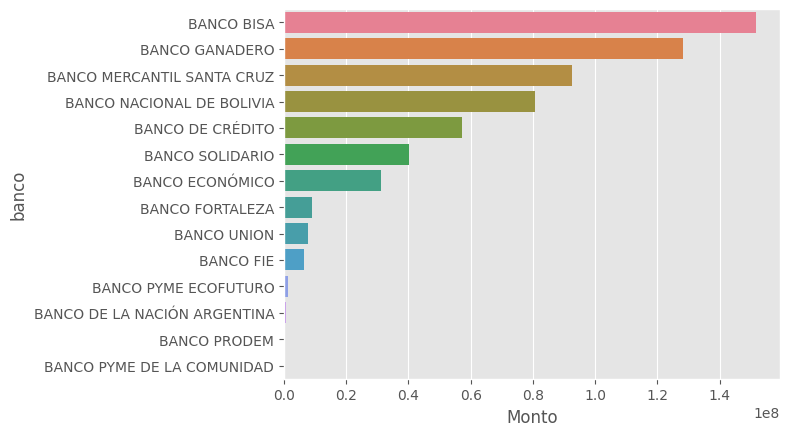

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

bancos_montos = df[df['banco'] != 'TOTAL BANCOS'].groupby(['banco']).agg({'Monto':'sum'})
plt.style.use('ggplot')
sns.barplot(data = bancos_montos.sort_values('Monto', ascending = False), y = 'banco', x = 'Monto', hue = 'banco', errorbar = None)
plt.show()

In [85]:
bancos_operaciones = df[df['banco'] != 'TOTAL BANCOS'].groupby(['fecha','banco']).agg({'Monto':'sum', 'N°':'sum'})
bancos_operaciones

Monto  N°
fecha      banco                                      
2026-06-26 BANCO BISA                    3957090.0  85
           BANCO DE CRÉDITO                21481.0  15
           BANCO DE LA NACIÓN ARGENTINA     7425.0   1
           BANCO ECONÓMICO               5194132.0  11
           BANCO FIE                           0.0   0
...                                            ...  ..
2026-07-29 BANCO PRODEM                    25950.0  16
           BANCO PYME DE LA COMUNIDAD       6397.0   6
           BANCO PYME ECOFUTURO           102330.0   5
           BANCO SOLIDARIO               1091581.0  52
           BANCO UNION                    113341.0  76

[322 rows x 2 columns]

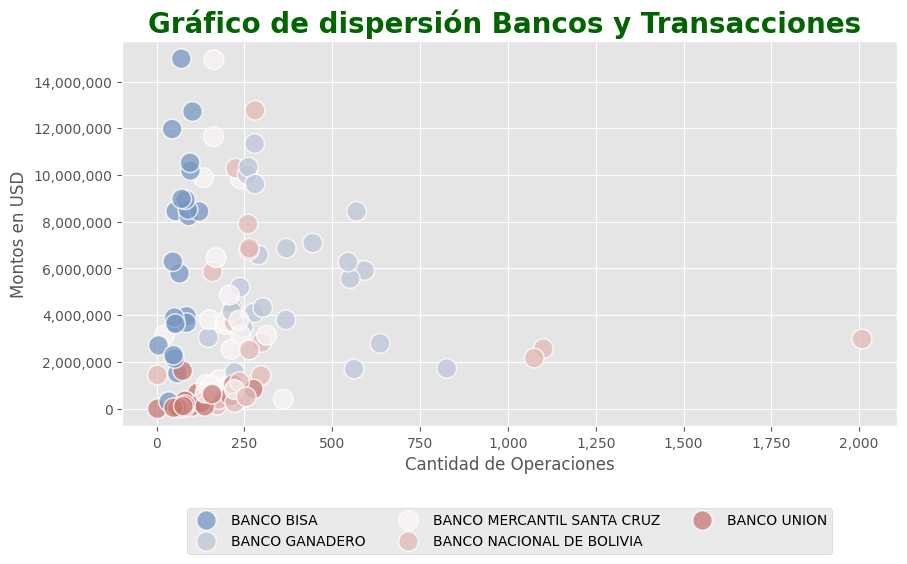

In [86]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = bancos_operaciones.query('banco.isin(["BANCO BISA", "BANCO GANADERO", "BANCO MERCANTIL SANTA CRUZ", "BANCO NACIONAL DE BOLIVIA", "BANCO UNION"])'),
                x = 'N°', y = 'Monto', hue = 'banco', alpha = 0.75, s = 200, palette = 'vlag')
plt.legend(loc = 'lower center', bbox_to_anchor=(0.5, -0.35), ncol = 3)
plt.ticklabel_format(style='plain', axis='both')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Cantidad de Operaciones')
plt.ylabel('Montos en USD')
plt.title('Gráfico de dispersión Bancos y Transacciones ', fontdict = dict(color = 'darkgreen', weight = 'bold', size = 20))
plt.show()

In [457]:
df.to_csv('df_canasta_bancos_operaciones_usd.csv', index = False)

In [1]:
import plotly.express as px

In [ ]:
# Gráfico del indice de calidad del aire

grap = px.line(
    tco,
    x = 'fecha',
    y = 'tco',
    markers = 'o',
    template = 'plotly_white',
)
grap.update_xaxes(
    tickmode="linear",
    dtick=86400000 * 4,
    tickformat="%m-%d",
    # tickangle=90
)
grap.show()

In [67]:
bancos_montos = informacion_anterior[informacion_anterior['banco'] != 'TOTAL BANCOS'].groupby(['fecha','banco']).agg({'Monto':'sum'}).reset_index()
bancos_montos['fecha'] = pd.to_datetime(bancos_montos['fecha'])
bancos_montos['fecha_formato'] = bancos_montos['fecha'].dt.strftime('%d-%m')
bancos_montos

,fecha,banco,Monto,fecha_formato
0,2026-06-26,BANCO BISA,15828360.0,26-06
1,2026-06-26,BANCO DE CRÉDITO,85924.0,26-06
2,2026-06-26,BANCO DE LA NACIÓN ARGENTINA,29700.0,26-06
3,2026-06-26,BANCO ECONÓMICO,20776528.0,26-06
4,2026-06-26,BANCO FIE,0.0,26-06
...,...,...,...,...
359,2026-08-03,BANCO PRODEM,131295.0,03-08
360,2026-08-03,BANCO PYME DE LA COMUNIDAD,18849.0,03-08
361,2026-08-03,BANCO PYME ECOFUTURO,78480.0,03-08
362,2026-08-03,BANCO SOLIDARIO,4731951.0,03-08


In [97]:
bancos_montos = informacion_anterior[informacion_anterior['banco'] != 'TOTAL BANCOS'].groupby(['fecha','banco']).agg({'Monto':'sum'}).reset_index()
bancos_montos['fecha'] = pd.to_datetime(bancos_montos['fecha'])
bancos_montos['fecha_formato'] = bancos_montos['fecha'].dt.strftime('%d-%m')
grap2 = px.bar(
    bancos_montos,
    y = 'banco',
    x = 'Monto',
    color = 'banco',
    animation_frame = 'fecha_formato',
    range_x = [0, bancos_montos['Monto'].max() * 1.1],
    hover_data = ['Monto'],
    title = 'Montos Transaccionados por bancos'
)
grap2.update_layout(legend = dict(visible = False),
                    yaxis=dict(tickmode = 'linear', ticks = '', tickfont = dict(size = 8)),
                    updatemenus = [dict(visible = False)],
                    xaxis = dict(title = 'Montos Transaccionados'),
                    title = dict(xanchor = 'center', x = 0.5),
                    sliders = [dict(currentvalue = dict(prefix = 'Fecha: ',
                        visible = True,
                        xanchor = 'center'
        )
    )])

mi_plantilla = "<b>Monto:</b> %{x:,.0f}<extra></extra>"

grap2.update_traces(hovertemplate=mi_plantilla)

if grap2.frames:
    for frame in grap2.frames:
        for data in frame.data:
            data.hovertemplate = mi_plantilla

grap2.show()

In [57]:
bancos_operaciones = informacion_anterior[informacion_anterior['banco'] != 'TOTAL BANCOS'].groupby(['fecha','banco']).agg({'Monto':'sum', 'N°':'sum'}).reset_index()
grap3 = px.scatter(
    bancos_operaciones.query('banco.isin(["BANCO BISA", "BANCO GANADERO", "BANCO MERCANTIL SANTA CRUZ", "BANCO NACIONAL DE BOLIVIA", "BANCO UNION"])'),
    x = 'N°',
    y = 'Monto',
    color = 'banco',
    size="Monto",
    size_max = 30
)
grap3.update_layout(
    legend = dict(yanchor = 'bottom', y = -0.3, orientation = 'h'),
    xaxis = dict(title = 'Cantidad Operaciones'),
    width = 850
)
grap3.show()

In [59]:
import dash
from dash import dcc, html

app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("📊 Mi Reporte Interactivo en GitHub"),
    html.P("Este reporte fue diseñado con Dash y Plotly."),
    dcc.Graph(id="grafico-principal", figure=grap)
])

if __name__ == "__main__":
    # Para previsualizar localmente antes de subir a GitHub:
    app.run(debug=True)